# CNN 

## Importamos Librerias

In [112]:
import random
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torchvision
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import DataLoader, Subset
from collections import Counter
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
SEED = 1
IMG_SIZE = 200
BATCH_SIZE = 64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

Dispositivo: cuda


## Rutas 

In [ ]:
PROJECT_ROOT = Path.cwd().parent

DATASET_DIR = ( PROJECT_ROOT /"Dataset" /"Insectos")

MODEL_DIR = PROJECT_ROOT / "CNN" / "modelos"
RESULTS_DIR = PROJECT_ROOT / "CNN" / "resultados"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


Proyecto: c:\Users\ASUS TUF GAMING A15\Desktop\erick\cico\2026\2-26\SIS421\Labs\Lab1
Dataset: c:\Users\ASUS TUF GAMING A15\Desktop\erick\cico\2026\2-26\SIS421\Labs\Lab1\Dataset\Insectos
Existe dataset: True


## Cargamos el Dataset

In [ ]:
base_dataset = datasets.ImageFolder(DATASET_DIR)

classes = base_dataset.classes
num_classes = len(classes)

print("Cantidad de datos =", len(base_dataset), "Cantidad de clases =", num_classes)
print("\nClases encontradas:")
for i, clase in enumerate(classes):
    print(f"{i:2d} = {clase}")

Cantidad de datos = 20325 Cantidad de clases = 23

Clases encontradas:
 0 = Abeja
 1 = Abeja Malifera (Apis)
 2 = Abejorro (Bombus)
 3 = Avispa
 4 = Chinche
 5 = Chinche rayada
 6 = Escarabajo
 7 = Escarabajo floricola (Oedem)
 8 = Hormiga
 9 = Lepidóptero (Mariposa-Polilla)
10 = Mariquita
11 = Mosca
12 = Mosca cernidora (Episyrphus)
13 = Mosca cernidora (Eristalis)
14 = Mosca cernidora (Eupeodes)
15 = Mosca cernidora (Myathropa)
16 = Mosca cernidora (Sphaerophoria)
17 = Mosca cernidora (Syrphus)
18 = Mosca danzante (Empididae)
19 = Mosca de la carne (Sarcophagidae)
20 = Mosca escorpión
21 = Mosca pequeña
22 = other


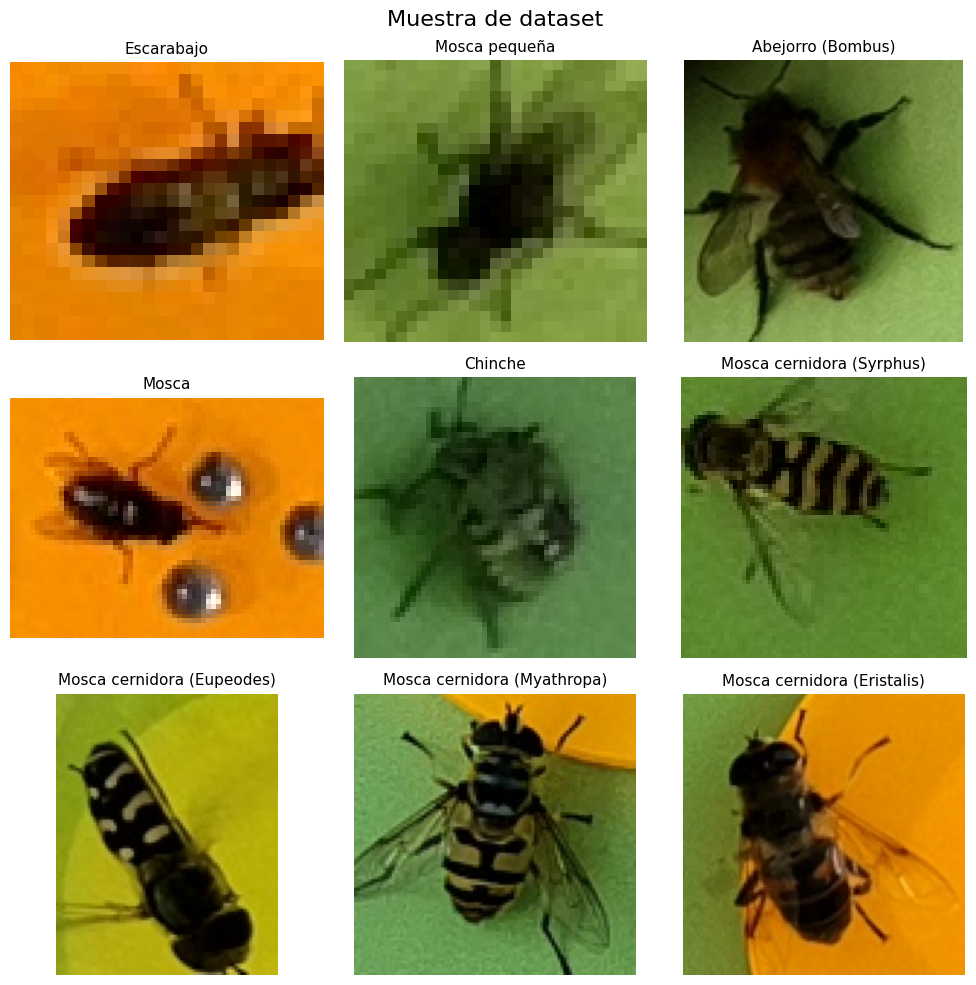

In [116]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

indices_aleatorios = random.sample(range(len(base_dataset)), 9)

for i, idx in enumerate(indices_aleatorios):
    imagen, etiqueta = base_dataset[idx]
    nombre_clase = classes[etiqueta]
    
    axes[i].imshow(imagen)
    axes[i].set_title(nombre_clase, fontsize=11)
    axes[i].axis("off")

plt.suptitle("Muestra de dataset", fontsize=16)
plt.tight_layout()
plt.show()

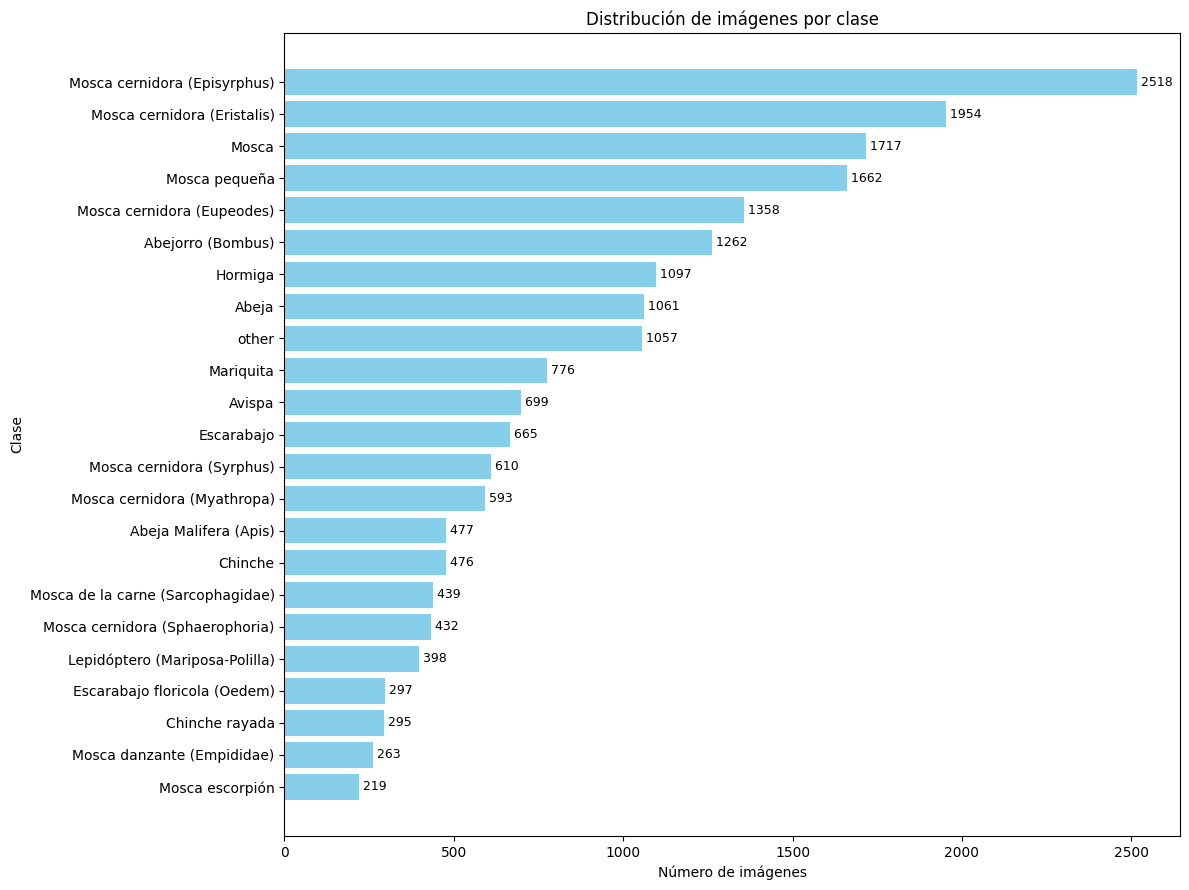

In [117]:
conteo = Counter(base_dataset.targets)
cantidad_por_clase = {classes[i]: conteo[i] for i in range(len(classes))}

clases_ordenadas = sorted(cantidad_por_clase, key=cantidad_por_clase.get)
cantidades_ordenadas = [cantidad_por_clase[clase] for clase in clases_ordenadas]

plt.figure(figsize=(12, 9))
plt.barh(clases_ordenadas, cantidades_ordenadas, color='skyblue')

plt.xlabel("Número de imágenes")
plt.ylabel("Clase")
plt.title("Distribución de imágenes por clase")

for i, cantidad in enumerate(cantidades_ordenadas):
    plt.text(cantidad, i, f" {cantidad}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Data Augmentation

In [118]:
train_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomVerticalFlip(p=0.5),   
    transforms.RandomRotation(45),          
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Creamos las particiones y los dataloaders

In [119]:
targets = base_dataset.targets
indices = list(range(len(targets)))

train_idx, temp_idx, train_targets, temp_targets = train_test_split(
    indices, targets, test_size=0.2, stratify=targets, random_state=SEED
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_targets, random_state=SEED
)

print(f"Datos de Entrenamiento : {len(train_idx)}")
print(f"Datos de Validación    : {len(val_idx)}")
print(f"Datos de Prueba (Test) : {len(test_idx)}")

Datos de Entrenamiento : 16260
Datos de Validación    : 2032
Datos de Prueba (Test) : 2033


In [ ]:
class DatasetTransformWrapper(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset) 

train_subset = Subset(base_dataset, train_idx)
val_subset = Subset(base_dataset, val_idx)
test_subset = Subset(base_dataset, test_idx)

train_dataset = DatasetTransformWrapper(train_subset, transform=train_transforms)
val_dataset = DatasetTransformWrapper(val_subset, transform=test_transforms)
test_dataset = DatasetTransformWrapper(test_subset, transform=test_transforms)

train_class_counts = Counter(train_targets)

class_weights = {clase: 1.0 / count for clase, count in train_class_counts.items()}

pesos_muestras = [class_weights[target] for target in train_targets]
pesos_muestras = torch.tensor(pesos_muestras, dtype=torch.float)

sampler = WeightedRandomSampler(
    weights=pesos_muestras,
    num_samples=len(pesos_muestras),
    replacement=True
) 

In [ ]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    sampler=sampler,   
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
)

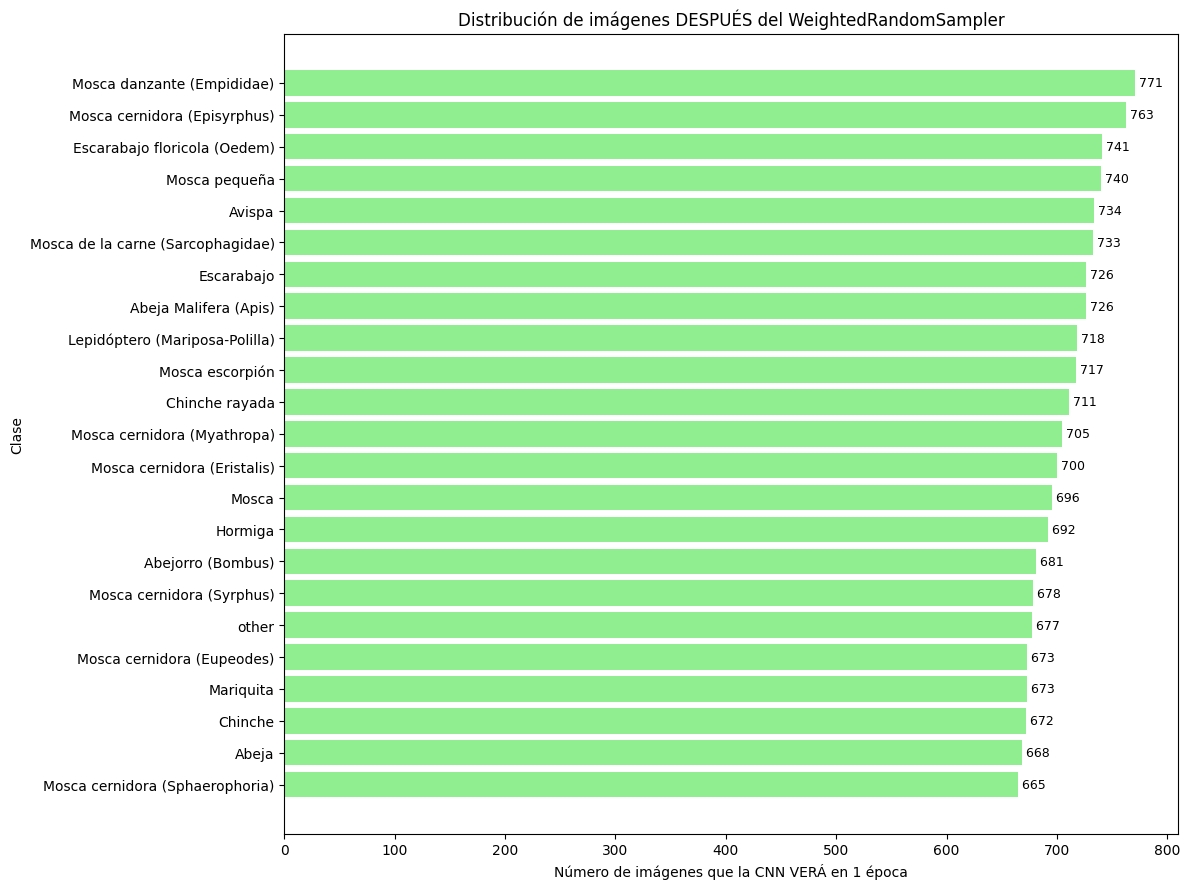

In [ ]:
etiquetas_muestreadas = []


for _, etiquetas in train_loader:
    # Guardamos las etiquetas de este lote (batch)
    etiquetas_muestreadas.extend(etiquetas.tolist())

# Contamos cuántas veces fue seleccionada cada clase por el Sampler
conteo_balanceado = Counter(etiquetas_muestreadas)

cantidades_balanceadas = [conteo_balanceado[i] for i in range(num_classes)]
nombres_clases = [classes[i] for i in range(num_classes)]

# Unimos nombres y cantidades, y los ordenamos para el gráfico
datos_grafico = list(zip(nombres_clases, cantidades_balanceadas))
datos_grafico.sort(key=lambda x: x[1])  # Ordenar de menor a mayor

clases_ord = [x[0] for x in datos_grafico]
cantidades_ord = [x[1] for x in datos_grafico]

# Generamos el nuevo gráfico
plt.figure(figsize=(12, 9))
plt.barh(clases_ord, cantidades_ord, color='lightgreen')

plt.xlabel("Número de imágenes que la CNN VERÁ en 1 época")
plt.ylabel("Clase")
plt.title("Distribución de imágenes DESPUÉS del WeightedRandomSampler")

# Mostrar número al lado de cada barra
for i, cantidad in enumerate(cantidades_ord):
    plt.text(cantidad, i, f" {cantidad}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

## Construccion de la CNN

In [ ]:
def block(c_in, c_out, k=3, p=1, s=1, pk=2, ps=2):
    return torch.nn.Sequential(
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s), # Capa convolucional
        torch.nn.ReLU(),                                      
        torch.nn.MaxPool2d(pk, stride=ps)                     
    )

class InsectCNN(torch.nn.Module):
    def __init__(self, n_channels=3, n_outputs=num_classes):
        super().__init__()

        self.conv1 = block(n_channels, 32) 
        self.conv2 = block(32, 64)           
        self.conv3 = block(64, 128)          
        self.conv4 = block(128, 256)         
        self.fc = torch.nn.Linear(256 * 12 * 12, n_outputs)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        
        x = x.view(x.shape[0], -1) 
        
        x = self.fc(x)
        return x

modelo_cnn = InsectCNN(n_channels=3, n_outputs=num_classes).to(device)


In [ ]:
from tqdm import tqdm

def fit(model, train_dataloader, val_dataloader, epochs=20):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.CrossEntropyLoss()
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(1, epochs+1):
        
        model.train()
        train_loss, train_acc = [], []
        
        bar = tqdm(train_dataloader, desc=f"Epoch {epoch}/{epochs} [Train]")
        
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
            
            optimizer.zero_grad()                   
            y_hat = model(X)                        
            loss = criterion(y_hat, y)              
            loss.backward()                         
            optimizer.step()                       
            
            train_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            train_acc.append(acc)
            
            bar.set_postfix(loss=f"{np.mean(train_loss):.5f}", acc=f"{np.mean(train_acc):.5f}")
            
        model.eval()
        val_loss, val_acc = [], []
        bar = tqdm(val_dataloader, desc=f"Epoch {epoch}/{epochs} [Val  ]")
        
        for batch in bar:
            X, y = batch
            X, y = X.to(device), y.to(device)
                
            y_hat = model(X)
            loss = criterion(y_hat, y)
                
            val_loss.append(loss.item())
            acc = (y == torch.argmax(y_hat, axis=1)).sum().item() / len(y)
            val_acc.append(acc)
                
            bar.set_postfix(val_loss=f"{np.mean(val_loss):.5f}", val_acc=f"{np.mean(val_acc):.5f}")
    
        history['train_loss'].append(np.mean(train_loss))
        history['train_acc'].append(np.mean(train_acc))
        history['val_loss'].append(np.mean(val_loss))
        history['val_acc'].append(np.mean(val_acc))
        
        print(f"Resultado -> loss: {np.mean(train_loss):.5f} | val_loss: {np.mean(val_loss):.5f} | acc: {np.mean(train_acc):.5f} | val_acc: {np.mean(val_acc):.5f}\n")
        
    return history

INICIANDO ENTRENAMIENTO DE LA CNN...


Epoch 1/20 [Train]:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 1/20 [Val  ]: 100%|██████████| 32/32 [00:04<00:00,  6.91it/s, val_acc=0.23519, val_loss=2.64657]


Resultado -> loss: 2.33714 | val_loss: 2.64657 | acc: 0.28775 | val_acc: 0.23519



Epoch 2/20 [Val  ]: 100%|██████████| 32/32 [00:04<00:00,  6.65it/s, val_acc=0.47559, val_loss=1.66280]


...

Resultado -> loss: 0.50423 | val_loss: 0.72637 | acc: 0.83811 | val_acc: 0.77588



Epoch 19/20 [Val  ]: 100%|██████████| 32/32 [00:04<00:00,  6.90it/s, val_acc=0.79362, val_loss=0.67878]


Resultado -> loss: 0.49388 | val_loss: 0.67878 | acc: 0.84283 | val_acc: 0.79362



Epoch 20/20 [Val  ]: 100%|██████████| 32/32 [00:04<00:00,  6.91it/s, val_acc=0.77132, val_loss=0.73735]

Resultado -> loss: 0.48235 | val_loss: 0.73735 | acc: 0.84461 | val_acc: 0.77132



GENERANDO CURVAS DE APRENDIZAJE


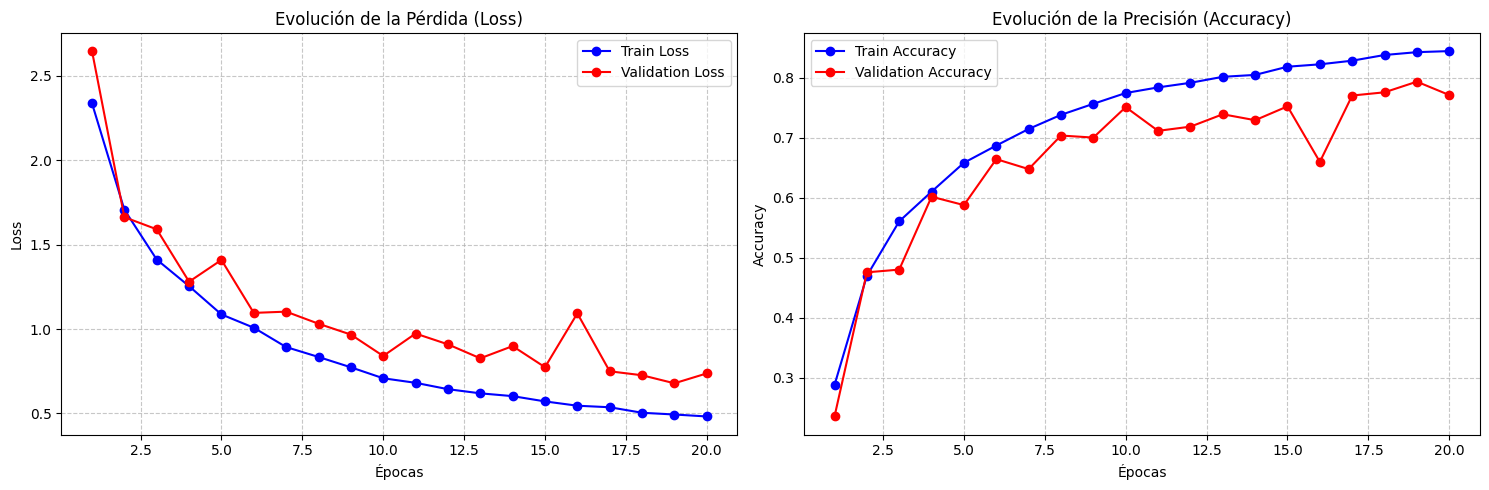


EVALUANDO MODELO Y GENERANDO MATRIZ DE CONFUSIÓN


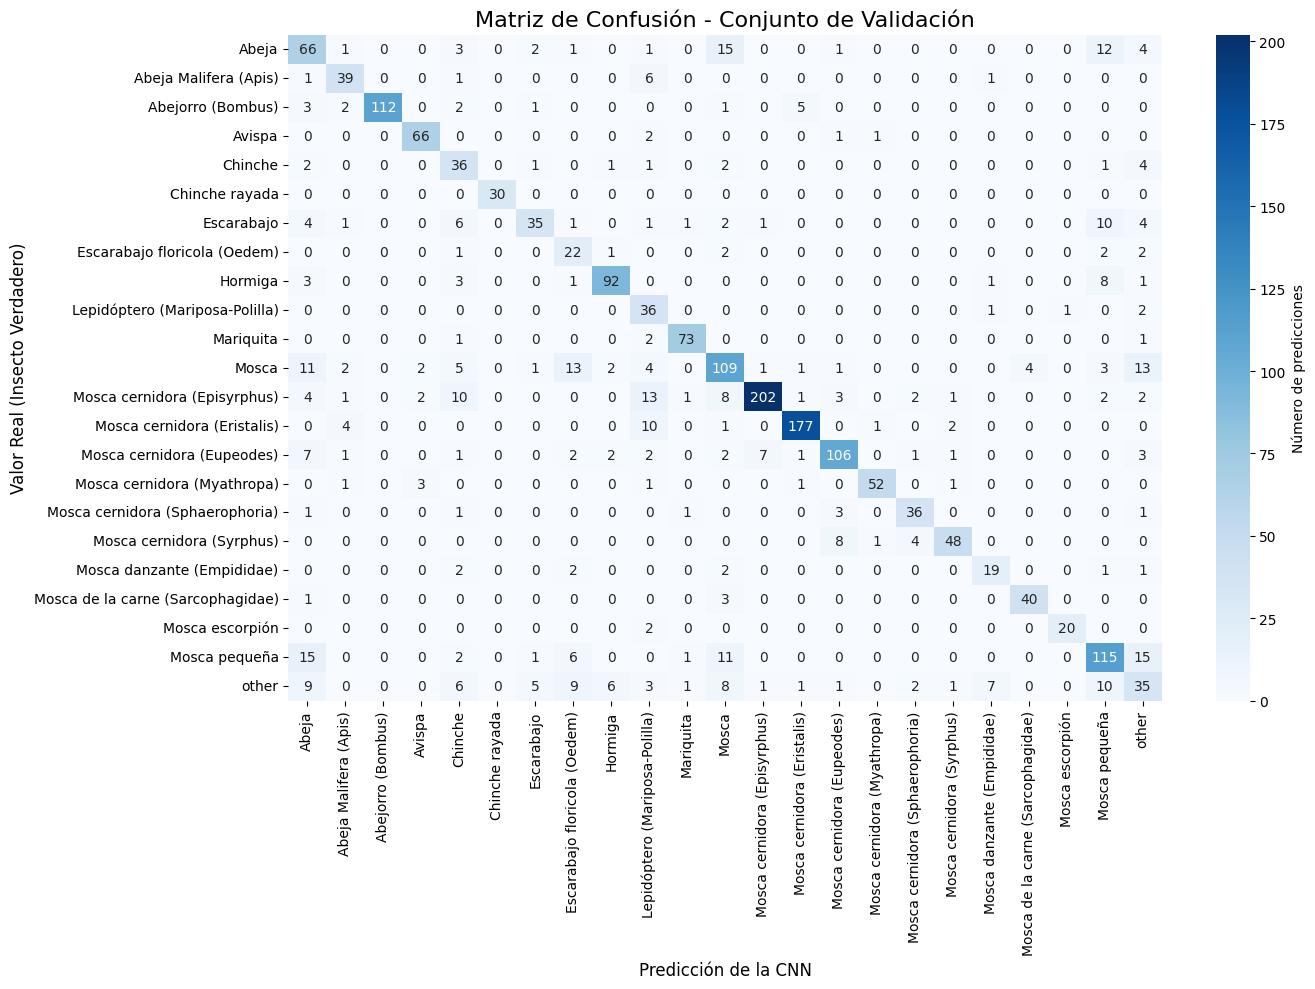

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report


def plot_learning_curves(history):
    epochs = range(1, len(history['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o', color='blue')
    ax1.plot(epochs, history['val_loss'], label='Validation Loss', marker='o', color='red')
    ax1.set_title('Evolución de la Pérdida (Loss)')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    ax2.plot(epochs, history['train_acc'], label='Train Accuracy', marker='o', color='blue')
    ax2.plot(epochs, history['val_acc'], label='Validation Accuracy', marker='o', color='red')
    ax2.set_title('Evolución de la Precisión (Accuracy)')
    ax2.set_xlabel('Épocas')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, dataloader, class_names):
    model.eval() 
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Número de predicciones'})
    
    plt.title('Matriz de Confusión - Conjunto de Validación', fontsize=16)
    plt.xlabel('Predicción de la CNN', fontsize=12)
    plt.ylabel('Valor Real (Insecto Verdadero)', fontsize=12)
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

evaluate_model(modelo_cnn, val_loader, classes)

In [126]:

# 1. Guardar los pesos (el cerebro) de tu CNN
ruta_modelo_cnn = MODEL_DIR / "cnn_desde_cero.pth"
torch.save(modelo_cnn.state_dict(), ruta_modelo_cnn)

# 2. Guardar el historial de entrenamiento (para las gráficas)
ruta_historial_cnn = RESULTS_DIR / "historial_cnn_desde_cero.pt"
torch.save(historial, ruta_historial_cnn)

print("¡Progreso guardado con éxito!")
print(f"Modelo    -> {ruta_modelo_cnn}")
print(f"Historial -> {ruta_historial_cnn}")

¡Progreso guardado con éxito!
Modelo    -> c:\Users\ASUS TUF GAMING A15\Desktop\erick\cico\2026\2-26\SIS421\Labs\Lab1\CNN\modelos\cnn_desde_cero.pth
Historial -> c:\Users\ASUS TUF GAMING A15\Desktop\erick\cico\2026\2-26\SIS421\Labs\Lab1\CNN\resultados\historial_cnn_desde_cero.pt
